<a href="https://colab.research.google.com/github/suvidhakarkera/HospitalReadmissionPredicition/blob/main/Regression%26Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 ML for Tabular Data — Hands On
### Predicting Insurance Charges
| Part | Task | Target | Algorithm |
|------|------|--------|-----------|
| **1 — Regression** | Predict the exact charge | `charges` (a number) | Linear Regression |
| **2 — Classification** | High cost or not? | `high_cost` (0 or 1) | Decision Tree |
✏️ — Fill in every `___` blank before running the cell. A 💡 Hint is shown above each blank.
---

## Setup

----------

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Setup complete — all libraries loaded!")


Setup complete — all libraries loaded!


## Data Loading

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

print("Dataset loaded!")

Dataset loaded!


## Exploratory Data Analysis (EDA)
#### First Look at the Data

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



❓ What columns do you see? Which one do you think we are predicting?

In [ ]:
df.shape

(1338, 7)

❓ 1,338 rows — is this a small or large dataset? In the real world, companies work with millions of rows!

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


❓ Which columns are numerical? Which are categorical (text)? Why does this matter for ML?

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


❓ Why would missing values be a problem when training a machine learning model?

In [ ]:
# 💡 Hint: Which function shows statistics like mean, min, max for every column?
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


❓ What is the average age? What is the average insurance charge?

## Visual Exploration

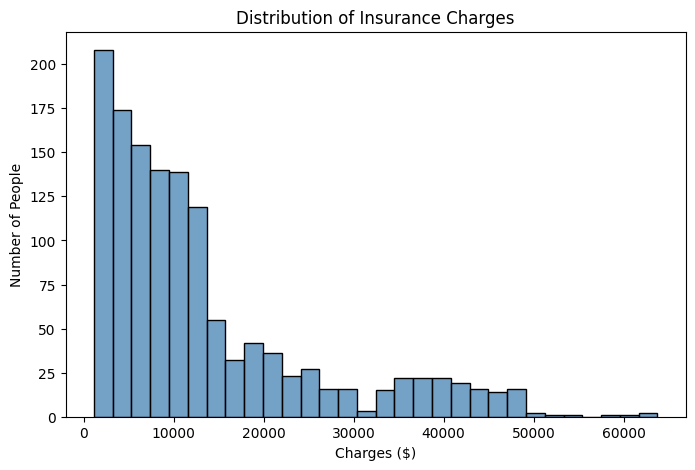

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], bins=30, color="steelblue")
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges ($)")
plt.ylabel("Number of People")
plt.show()

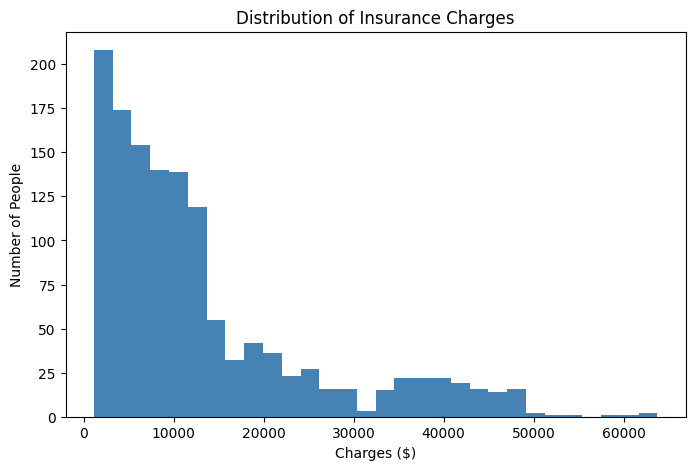

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30, color="steelblue")
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges ($)")
plt.ylabel("Number of People")
plt.show()

❓ Are most customers paying low charges or high charges? Is this a normal distribution or skewed?

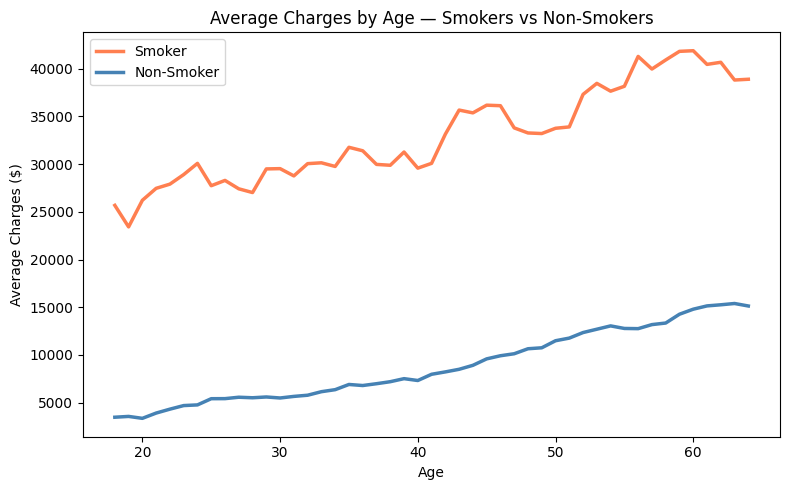

In [ ]:
avg_by_age = df.groupby(["age", "smoker"])["charges"].mean().reset_index()
avg_by_age["smoker"] = avg_by_age["smoker"].map({"yes": "Smoker", "no": "Non-Smoker"})

plt.figure(figsize=(8, 5))
for group, color in [("Smoker", "coral"), ("Non-Smoker", "steelblue")]:
    subset = avg_by_age[avg_by_age["smoker"] == group].sort_values("age")
    smoothed = subset["charges"].rolling(window=5, center=True, min_periods=1).mean()
    plt.plot(subset["age"], smoothed, color=color, label=group, linewidth=2.5)

plt.xlabel("Age")
plt.ylabel("Average Charges ($)")
plt.title("Average Charges by Age — Smokers vs Non-Smokers")
plt.legend()
plt.tight_layout()
plt.show()

❓ What pattern do you notice between the orange (smoker) and blue (non-smoker) groups?

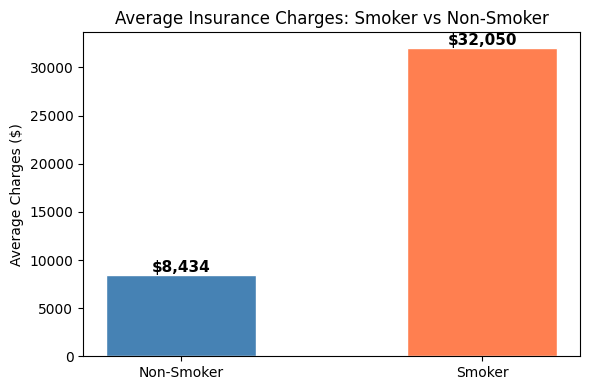

In [ ]:
avg_charges = df.groupby("smoker")["charges"].mean().reset_index()
avg_charges["smoker"] = avg_charges["smoker"].map({"yes": "Smoker", "no": "Non-Smoker"})

plt.figure(figsize=(6, 4))
bars = plt.bar(avg_charges["smoker"], avg_charges["charges"],
               color=["steelblue", "coral"], width=0.5, edgecolor="white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"${bar.get_height():,.0f}",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Average Insurance Charges: Smoker vs Non-Smoker")
plt.ylabel("Average Charges ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

❓ Which group pays significantly more? Why do you think insurance companies care about smoking status?

## Correlation Analysis

In [ ]:
corr = df.corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


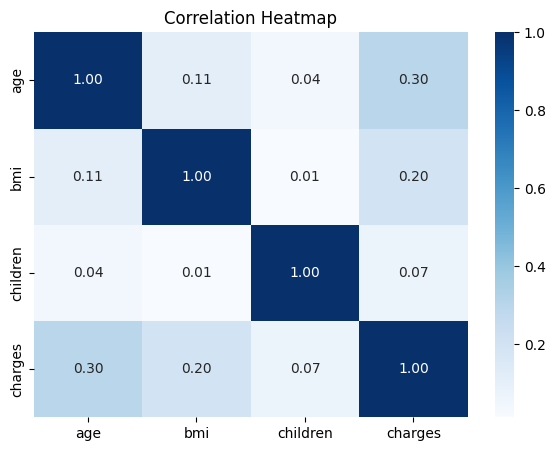

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

❓ Which feature has the strongest correlation with charges? Does this match what we saw in the charts?

## Data Cleaning

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 1337


## Feature Engineering
###  ML models only understand numbers. We convert text columns into 0s and 1s.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex','smoker', 'region'],   # 💡 Hint: Name the 3 categorical (text) columns to encode
    drop_first=True
)

df_encoded = df_encoded.astype(
    {c: int for c in df_encoded.select_dtypes("bool").columns}
)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (1337, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


❓ We started with 7 columns and now have more. Where did the new columns come from?

## Define Features and Target (X and y)
- **X** = all inputs (features) fed to the model
- **y** = what the model needs to predict (target)

In [ ]:

# 💡 Hint: X = all columns EXCEPT the target | y = the column we want to PREDICT
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
print("Features Shape:", X.shape)
print("Target Shape:  ", y.shape)
print("\nFeature Columns:")
print(X.columns.tolist())

Features Shape: (1337, 8)
Target Shape:   (1337,)

Feature Columns:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## Train-Test Split
**Training (80%)** = Textbook — model learns from this
**Testing (20%)** = Final Exam — model never sees this during training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # 💡 Hint: What fraction goes to testing? (20% = 0.2)
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing  rows:", X_test.shape[0])

Training rows: 1069
Testing  rows: 268


❓ Why do we hide 20% of the data from the model during training?

## Model Training — Linear Regression
`model.fit(X_train, y_train)` ← **this is where learning happens**

In [ ]:
model = LinearRegression()
# 💡 Hint: Which method TRAINS the model on the training data?
model.fit(X_train, y_train)

print("✅ Model Training Completed")
print("Trained on", X_train.shape[0], "examples")

NameError: name 'X_train' is not defined

## Coefficients — What Did the Model Learn?
Each coefficient = how much the predicted charge changes for a 1-unit increase in that feature.  
**Positive** = increases charge | **Negative** = decreases charge

In [ ]:

coefficients = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

 ❓ Which feature has the biggest impact on charges? Is `smoker_yes` at the top? What does the + or − sign mean?

## Predictions on Test Data
Run the trained model on the 20% test set — data the model has **never seen**.

In [ ]:
# 💡 Hint: Which method makes PREDICTIONS on unseen data?
predictions = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual":    y_test.values,
    "Predicted": predictions.round(2)
})
prediction_df.head(10)

## Evaluation Metrics
| Metric | Meaning | Better when |
|--------|---------|-------------|
| **MAE** | Average prediction error | Lower |
| **RMSE** | Like MAE but penalizes large errors more | Lower |
| **R²** | % of variation the model explains | Closer to 1.0 |

In [ ]:
mae  = mean_absolute_error(y_test, predictions)
mse  = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
# 💡 Hint: Use r2_score() — measures how much variation the model explains (0 to 1)
r2   = ________(y_test, predictions)

print("MAE  :", round(mae, 2),  " ← on average, off by this much")
print("RMSE :", round(rmse, 2), " ← penalizes large errors more")
print("R²   :", round(r2, 4),  " ← closer to 1 = better")

❓ If R² = 0.75, what does that mean in plain English?

## Actual vs Predicted — Visualization
Each dot = one person from the test set. Dots on the red line = perfect prediction.

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.4, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label="Perfect Prediction"
)
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Charges")
plt.legend()
plt.show()

❓ Where does the model struggle the most? Look for clusters of dots far from the red line — what type of patients are those?

## Predict for a New Customer
The model is trained and tested. Now use it on **completely new data** — this is exactly how it works in production.

In [ ]:
new_customer = pd.DataFrame({
    'age':              [35],
    'bmi':              [28.5],
    'children':         [2],
    'sex_male':         [1],
    'smoker_yes':       [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

predicted_charge = model.predict(new_customer)
print("New Customer: Age 35, BMI 28.5, 2 children, Non-smoker, Southeast")
print("Predicted Insurance Charge: $", round(predicted_charge[0], 2))

❓ Now change `smoker_yes` to `1` and re-run. By how much does the predicted charge increase?

 ---
 # PART 2: CLASSIFICATION
### “Will this person be expensive to insure?” → YES or NO
Same dataset. Same features. **Different question.**
We create a new target column `high_cost`:
- **1 = High Cost** (charges above the median)
- **0 = Low Cost** (charges at or below the median)
This is **Binary Classification** — predicting one of two categories.

## Create the Target Column — high_cost
Rule: if `charges > median` → **1 (High Cost)** else **0 (Low Cost)**
Using the median gives us a balanced 50/50 split — ideal for classification.


In [ ]:
df["high_cost"] = np.where(
    df["charges"] > df["charges"]._______(),  # 💡 Hint: Middle value function — gives a 50/50 split
    1,
    0
)
print("Median charge: $", round(df["charges"].median(), 2))

❓ Why do we use the median as the threshold? What advantage does that give us?


## Class Distribution

In [ ]:
df["high_cost"].value_counts()

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x="high_cost", data=df, palette=["steelblue", "coral"])
plt.xticks([0, 1], ["Low Cost (0)", "High Cost (1)"])
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

❓ Is the dataset balanced (roughly equal 0s and 1s)? Why does class balance matter when training a classifier?

## Reuse Encoded Features from Part 1
Feature engineering is already done — `df_encoded` is ready to use.

In [ ]:
df_encoded.head()

## Define Features and Target (X and y)
Drop `charges` so the model cannot cheat — `high_cost` was created from `charges`!

In [ ]:
# 💡 Hint: Drop the column that would cheat — high_cost was built FROM this column
X = df_encoded.drop(["________"], axis=1)
y = df["high_cost"]

print("Features:", X.shape[1], "columns")
print("Target classes:", y.unique())

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=_    # 💡 Hint: Pass the target variable to keep class balance in train and test
)
print("Training rows:", X_train.shape[0])
print("Testing  rows:", X_test.shape[0])

❓ Why do we add `stratify=y` this time? What problem does it prevent?


## Model Training — Decision Tree
A Decision Tree learns IF/ELSE rules from data:  
*"Is smoker = Yes? → likely High Cost. If No, check age..."*


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 💡 Hint: Keep max_depth small! Too deep = memorising not learning. Try 3.
model = DecisionTreeClassifier(max_depth=___, random_state=42)
model.fit(X_train, y_train)

print("✅ Decision Tree trained!")
print("Max depth used:", model.get_depth())

❓ Why do we set `max_depth=3`? What would happen if we set it to 10 or 20?


## Predictions

In [ ]:
predictions = model.predict(X_test)

result_preview = pd.DataFrame({
    "Actual":    y_test.values[:10],
    "Predicted": predictions[:10]
})
print(result_preview.to_string(index=False))


 ## Evaluation
 **Accuracy** = % of correct predictions   
 **Classification Report** = detailed precision, recall, F1 per class

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 💡 Hint: Use accuracy_score() — what % did the model classify correctly?
accuracy = _____________(y_test, predictions)
print("Accuracy:", round(accuracy * 100, 2), "%\n")

print(classification_report(
    y_test,
    predictions,
    target_names=["Low Cost (0)", "High Cost (1)"]
))


❓ What is the difference between Precision and Recall? When would you care more about Recall than Accuracy?

## Confusion Matrix
| Predicted Low | Predicted High |
|--------------|----------------|
| **Actual Low** | True Neg ✔ | False Pos ✘ |
| **Actual High** | False Neg ✘ | True Pos ✔ |

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Cost", "High Cost"],
    yticklabels=["Low Cost", "High Cost"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

❓ What do the off-diagonal numbers mean? Which error (False Positive or False Negative) is more costly in insurance?

## Feature Importance
Which features did the Decision Tree rely on most to make its decisions?

In [ ]:
importance = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

❓ Does the most important feature here match what we discovered in the EDA charts earlier?


## Predict for a New Customer

In [ ]:
new_customer = pd.DataFrame({
    'age':              [35],
    'bmi':              [28.5],
    'children':         [2],
    'sex_male':         [1],
    'smoker_yes':       [1],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

prediction  = model.predict(new_customer)
probability = model.predict_proba(new_customer)[0]

print("New Customer: Age 35, BMI 28.5, 2 children, SMOKER, Southeast")
print("Prediction:", "HIGH COST" if prediction[0] == 1 else "LOW COST")
print(f"Confidence: Low Cost = {probability[0]:.1%} | High Cost = {probability[1]:.1%}")

❓ Now change `smoker_yes` to `0` and re-run — does the prediction change from HIGH COST to LOW COST?